# 과제 1 - SVM 회귀


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [14]:
# 데이터 로드
california_housing = fetch_california_housing(as_frame=True)
X, y = california_housing.data, california_housing.target

# 위, 경도 데이터 열 삭제
X = X.drop('Latitude', axis = 1)
X = X.drop('Longitude', axis = 1)

# 데이터 스케일
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


In [8]:
X # 독립변수 column 6개, 종속변수 1개

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467
...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209


In [9]:
# 모델 생성
svr = SVR(epsilon = 0.01) # epsilon -> 허용 오차

# 모델 훈련
svr.fit(X_train, y_train)


SVR(epsilon=0.01)

In [10]:
# 예측
y_pred_scaled = svr.predict(X_test)

# 스케일 복원
y_test = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

# 성능 평가
mse = mean_squared_error(y_test, y_pred) # MSE loss -> 회귀니까
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 0.45835891638101556
R-squared: 0.6502168986995807


In [6]:
print(y_pred)

[[0.75859982]
 [1.36685297]
 [3.78972841]
 ...
 [4.62704727]
 [1.07361099]
 [1.75725154]]


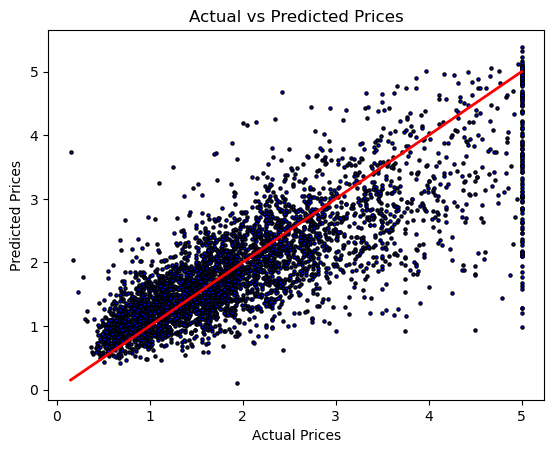

In [7]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요

In [21]:
# 데이터 로드
california_housing = fetch_california_housing(as_frame=True)
X, y = california_housing.data, california_housing.target

# 위, 경도 데이터 열 삭제
X = X.drop('Latitude', axis = 1)
X = X.drop('Longitude', axis = 1)

# 데이터 스케일
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# 모델 생성
your_svr = SVR(epsilon=1) # epsilon을 0.01에서 0.1로 증가시킴

# 모델 훈련
your_svr.fit(X_train, y_train)


SVR(epsilon=1)

In [22]:
# 예측
y_pred_scaled_after = your_svr.predict(X_test)

# 스케일 복원
y_test = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_pred_after = scaler_y.inverse_transform(y_pred_scaled_after.reshape(-1,1))

# 성능 평가
mse = mean_squared_error(y_test, y_pred_after) # MSE loss -> 회귀니까
r2 = r2_score(y_test, y_pred_after)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 0.573791017939106
R-squared: 0.5621282916503165


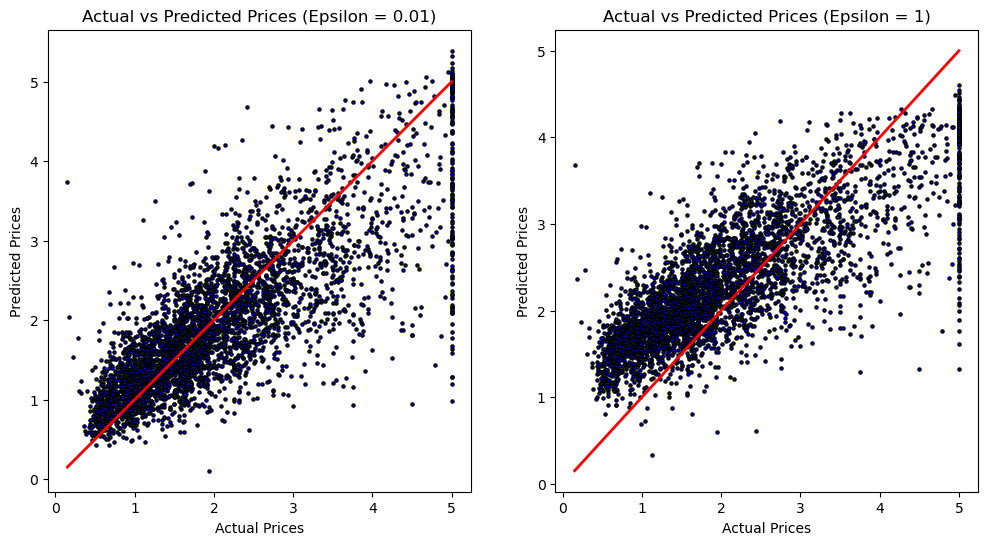

In [24]:

# 일부 feature를 사용하여 2D로 시각화

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Epsilon = 0.01)')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_after, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Epsilon = 1)')
plt.show()

## Before (epsilon = 0.01)
Mean Squared Error: 0.45835891638101556
R-squared: 0.6502168986995807

## After (epsilon = 1)
Mean Squared Error: 0.573791017939106
R-squared: 0.5621282916503165

## 비교분석

Epsilon을 0.1로 100배가량 확대하였을 때 MSE, R^2 metric에서 모두 성능이 하락. (MSE loss 증가, R-Squared 감소)
Epsilon을 증가시켰을 때, 모델의 fit 속도가 증가 (소요시간 3.4초 -> 1초)

Epsilon을 증가하자, 손실 함수의 최적화 문제에서 초평면의 복잡도가 감소하였기 때문에, underfitting이 발생하여 성능이 감소하였다.

시각화한 그래프의 두 이미지에서도, epsilon을 증가시키자 정답인 y=x에서 객체들이 멀어진 것을 확인할 수 있고, 모델이 언더피팅되어 actual price보다 높은 값을 예측하는 경향성이 발생하였다.

# 과제 1-2 : SVM 분류

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [33]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
X_train.shape # 컬럼 4개 . feature 4개

(120, 4)

## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

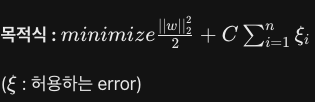


In [41]:
# 다양한 trade-off 파라미터 C 값 설정
C_values = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000, 10000, 100000, 1000000] # C가 높아질수록, 모델의 오차를 엄격하게 본다는 것이기 때문에 overfitting에 취약해짐
train_accuracies = []
test_accuracies = []

w_s = []
b_s = []

for C in C_values:
    # 모델 생성
    svc = LinearSVC(C=C)

    # 모델 훈련
    svc.fit(X_train, y_train)

    # 학습된 모델의 가중치 확인
    w = svc.coef_[0]
    b = svc.intercept_[0]

    w_s.append(w)
    b_s.append(b)

    # 훈련 데이터와 테스트 데이터에 대한 예측
    y_train_pred = svc.predict(X_train)
    y_test_pred = svc.predict(X_test)

    # 정확도 계산
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 결과 저장
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # 성능 출력
    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc}")
    print(f"Testing Accuracy: {test_acc}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)


C=0.001:
Training Accuracy: 0.6583333333333333
Testing Accuracy: 0.7
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.00      0.00      0.00         9
           2       0.55      1.00      0.71        11

    accuracy                           0.70        30
   macro avg       0.52      0.67      0.57        30
weighted avg       0.54      0.70      0.59        30

--------------------------------------------------
C=0.01:
Training Accuracy: 0.8
Testing Accuracy: 0.8333333333333334
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

----

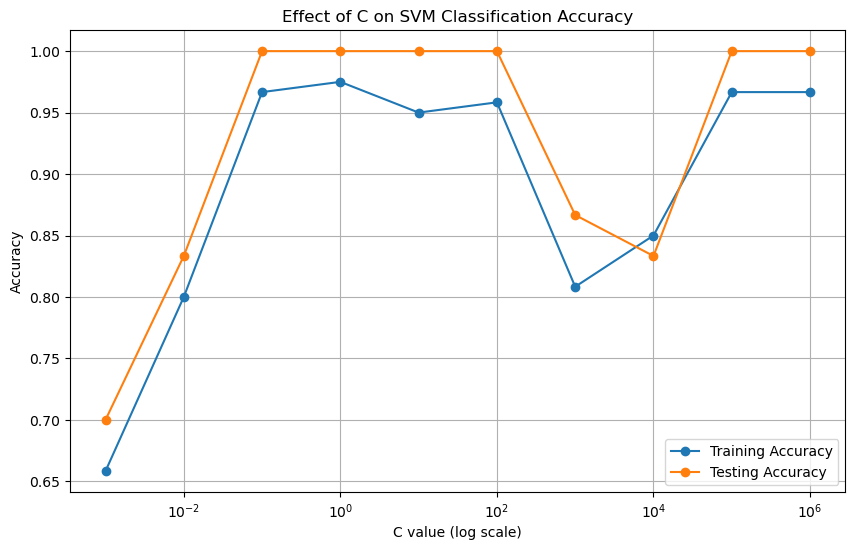

In [40]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [48]:
for i, w in enumerate(w_s):
    squared_sum = np.sum(w**2)
    print(f'C값은, = {C_values[i]}, weight 제곱합은, {squared_sum}')

C값은, = 0.001, weight 제곱합은, 0.039839491963536276
C값은, = 0.01, weight 제곱합은, 0.2832950587781855
C값은, = 0.1, weight 제곱합은, 0.6041202610213111
C값은, = 1.0, weight 제곱합은, 1.0934751358889625
C값은, = 10, weight 제곱합은, 1.6376131912592244
C값은, = 100, weight 제곱합은, 1.7426657180404468
C값은, = 1000, weight 제곱합은, 1.7538954049047368
C값은, = 10000, weight 제곱합은, 1.7550370452565596
C값은, = 100000, weight 제곱합은, 1.7551408832972206
C값은, = 1000000, weight 제곱합은, 1.7551579385439626


## C 값에 따른 성능 변화

### C가 높다는 말은, 오차를 더욱 엄격하게 확인한다는 말 -> 지나치게 높은 C는 overfitting에 취약하다

-> 너무 낮은 C < 0.01에서 성능이 감소하였다. 그 이유는, 너무 작은 C는 모델을 지나치게 단순히 만든다. -> weight squared sum이 지나치게 감소하여 underfit

-> 너무 높은 C > 100에서 성능이 증가하였다. 그 이유는, 너무 높은 C는 모델의 복잡성을 높인다. -> weighted squred sum이 지나치게 증가하고, overfit되었다.


#### 적절한 하이퍼파라미터 선정이 머신러닝에서 중요.
